OpenCV 

In [2]:
import cv2  # OpenCV library
import numpy as np
from matplotlib import pyplot as plt

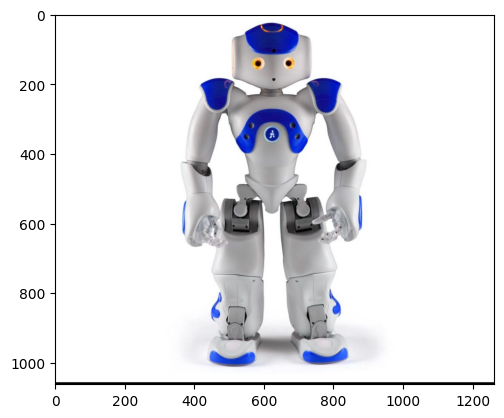

In [3]:
# Load an image
Red = cv2.imread("egfile/robotred.png")

# Show the image
plt.imshow(Red) 

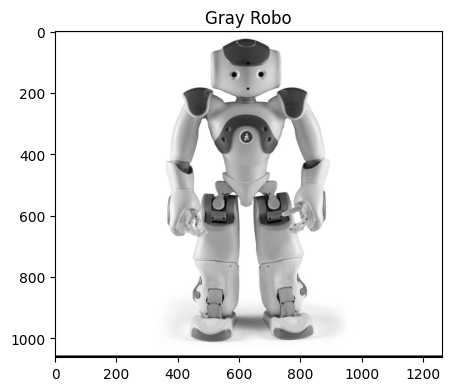

In [5]:
plt.figure(figsize=(5,5))
Gray=cv2.imread("egfile/robotred.png", cv2. IMREAD_GRAYSCALE)
plt.imshow(Gray)
plt.title("Gray Robo")
#plt.axis("off")
plt.imshow(Gray,cmap='gray')

In [ ]:
cv2.imwrite("egfile/grayscale_image.jpg", Gray)
# to save new image

True

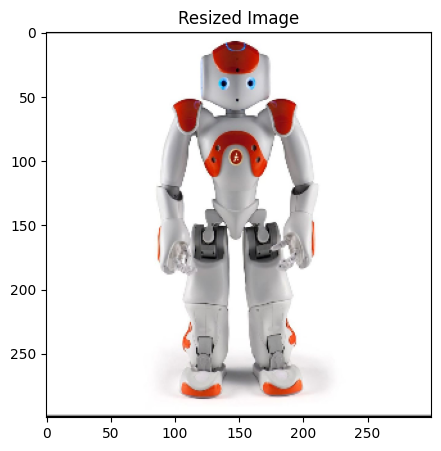

In [6]:
# Resize Image
resized_image = cv2.resize(Red, (300, 300))
plt.figure(figsize=(5,5))
plt.imshow(cv2.cvtColor(resized_image, cv2.COLOR_BGR2RGB))
plt.title("Resized Image")
#plt.axis("off")
plt.show()

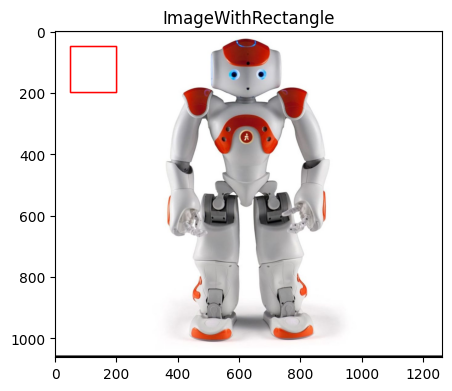

In [7]:
# Draw Shapes on Image
image_with_rectangle = Red.copy()
cv2.rectangle(image_with_rectangle, (50, 50), (200, 200), (0, 0, 255), 3)
plt.figure(figsize=(5,5))
plt.imshow(cv2.cvtColor(image_with_rectangle, cv2.COLOR_BGR2RGB))
plt.title("ImageWithRectangle")
#plt.axis("off")
plt.show()

Canny's Edge Detection

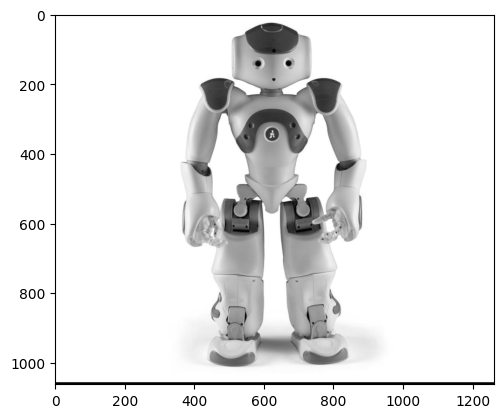

In [8]:
# Convert to Grayscale
gray = cv2.imread("egfile/robotred.png", cv2.IMREAD_GRAYSCALE)
plt.imshow(gray,cmap='gray')

In [9]:
# Apply Gaussian Blur
#blurred = cv2.GaussianBlur(gray, (5, 5), 0)

In [10]:
# Perform Canny Edge Detection
edges = cv2.Canny(gray, 100, 200)

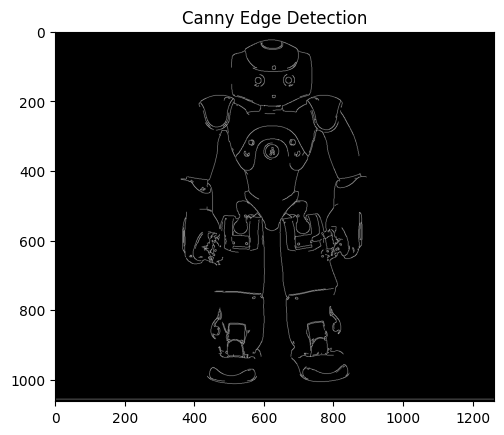

In [11]:
#plot them
plt.imshow(edges, cmap="gray")
plt.title("Canny Edge Detection")
#plt.axis("off")
plt.show()

#Histograms

In [12]:
equalized_image = cv2.equalizeHist(Gray)

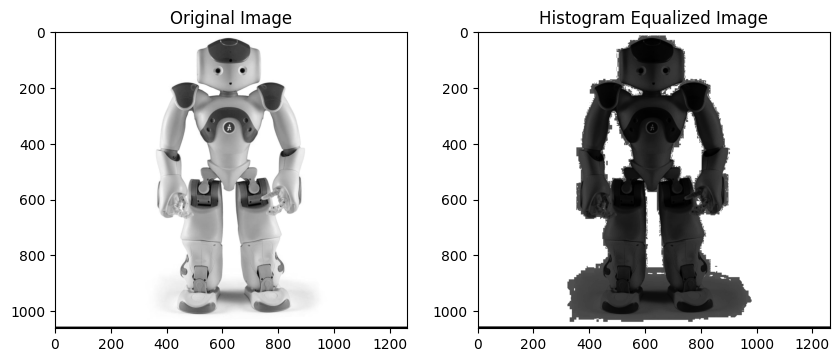

In [13]:
# Displaying original and equalized images
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
# (rows, columns, index) -> 1 row, 2 columns, first subplot
plt.imshow(Gray, cmap='gray')
plt.title("Original Image")
#plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(equalized_image, cmap='gray')
plt.title("Histogram Equalized Image")
#plt.axis("off")

plt.show()

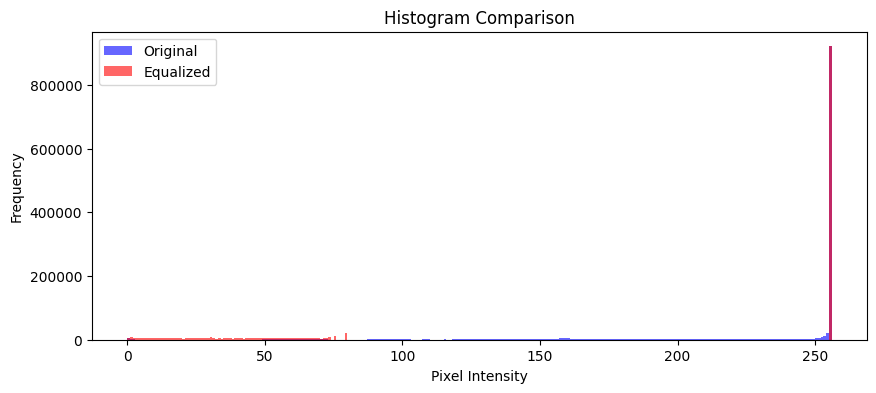

In [14]:
plt.figure(figsize=(10, 4))
plt.hist(Gray.ravel(), 256, [0,256], label="Original", color='blue', alpha=0.6)
plt.hist(equalized_image.ravel(), 256, [0,256], label="Equalized", color='red', alpha=0.6)
plt.title("Histogram Comparison")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [15]:
cv2.imwrite("egfile/EqualizedOfGray.jpg", equalized_image)

True

In [16]:
img = cv2.imread('egfile/robotred.png',0)

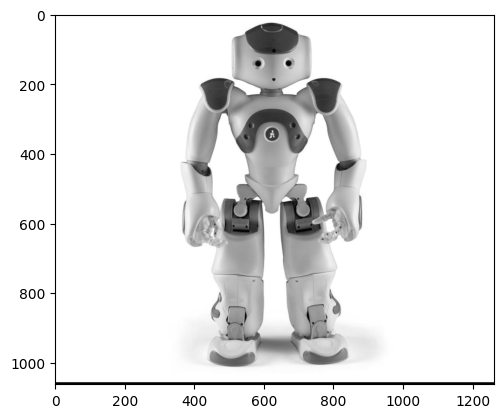

In [17]:
plt.imshow(img,'gray')

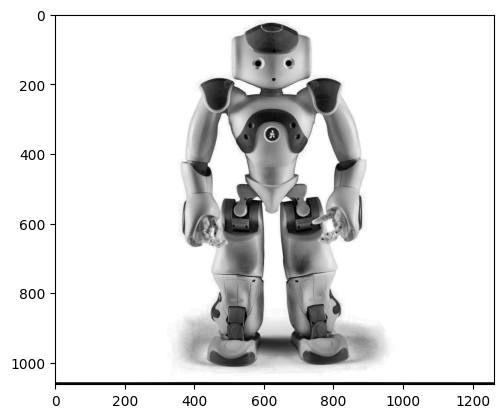

In [18]:
#CLAHE
#improves image contrast
clahe = cv2.createCLAHE(clipLimit=5.0, tileGridSize=(8,8))
cl1 = clahe.apply(img)
plt.imshow(cl1,'gray')

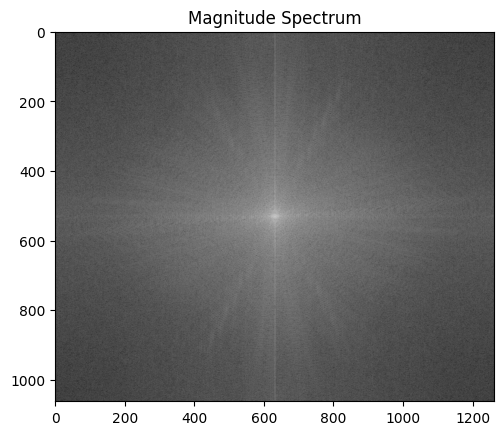

In [19]:
# Apply 2D Fourier Transform
f = np.fft.fft2(img)

# Shift the zero frequency component to the center
fshift = np.fft.fftshift(f)

# Compute the magnitude spectrum
magnitude_spectrum = 20 * np.log(np.abs(fshift))

plt.imshow(magnitude_spectrum, cmap='gray')
plt.title('Magnitude Spectrum')
plt.show()

In [20]:
rows, cols = img.shape
crow, ccol = rows//2, cols//2
fshift[crow-30:crow+31, ccol-30:ccol+31] = 0
f_ishift = np.fft.ifftshift(fshift)
img_back = np.fft.ifft2(f_ishift)
img_back = np.real(img_back)

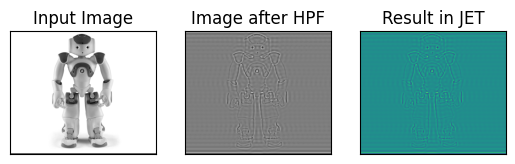

In [21]:
plt.subplot(131),plt.imshow(img, cmap = 'gray')
plt.title('Input Image'), plt.xticks([]), plt.yticks([])
plt.subplot(132),plt.imshow(img_back, cmap = 'gray')
plt.title('Image after HPF'), plt.xticks([]), plt.yticks([])
plt.subplot(133),plt.imshow(img_back)
plt.title('Result in JET'), plt.xticks([]), plt.yticks([])
 
plt.show()

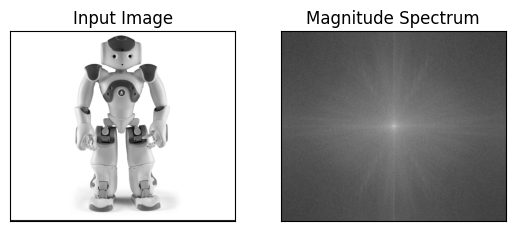

In [ ]:
dft = cv2.dft(np.float32(img),flags = cv2.DFT_COMPLEX_OUTPUT)
dft_shift = np.fft.fftshift(dft)
 
magnitude_spectrum = 20*np.log(cv2.magnitude(dft_shift[:,:,0],dft_shift[:,:,1]))

plt.subplot(121),plt.imshow(img, cmap = 'gray')
plt.title('Input Image'), plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(magnitude_spectrum, cmap = 'gray')
plt.title('Magnitude Spectrum'), plt.xticks([]), plt.yticks([])
plt.show()

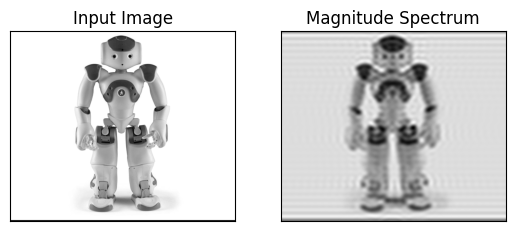

In [23]:
rows, cols = img.shape
crow, ccol = rows//2, cols//2
 
# create a mask first, center square is 1, remaining all zeros
mask = np.zeros((rows,cols,2),np.uint8)
mask[crow-30:crow+30, ccol-30:ccol+30] = 1
 
# apply mask and inverse DFT
fshift = dft_shift*mask
f_ishift = np.fft.ifftshift(fshift)
img_back = cv2.idft(f_ishift)
img_back = cv2.magnitude(img_back[:,:,0],img_back[:,:,1])
 
plt.subplot(121),plt.imshow(img, cmap = 'gray')
plt.title('Input Image'), plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(img_back, cmap = 'gray')
plt.title('Magnitude Spectrum'), plt.xticks([]), plt.yticks([])
plt.show()

In [24]:
#WaterShed Segmentation

In [34]:
ret, thresh = cv2.threshold(gray,0,255,cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU)

In [37]:
# noise removal
kernel = np.ones((3,3),np.uint8)
opening = cv2.morphologyEx(thresh,cv2.MORPH_OPEN,kernel, iterations = 2)
 
# sure background area
sure_bg = cv2.dilate(opening,kernel,iterations=3)
 
# Finding sure foreground area
dist_transform = cv2.distanceTransform(opening,cv2.DIST_L2,5)
ret, sure_fg = cv2.threshold(dist_transform,0.7*dist_transform.max(),255,0)
 
# Finding unknown region
sure_fg = np.uint8(sure_fg)
unknown = cv2.subtract(sure_bg,sure_fg)

In [39]:
# Marker labelling
ret, markers = cv2.connectedComponents(sure_fg)
 
# Add one to all labels so that sure background is not 0, but 1
markers = markers+1
 
# Now, mark the region of unknown with zero
markers[unknown==255] = 0

In [44]:
# Convert the image to grayscale
gray = cv2.cvtColor(Red, cv2.COLOR_BGR2GRAY)

# Apply a binary threshold to the image
ret, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# Remove noise with morphological operations
kernel = np.ones((3,3),np.uint8)
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)

# Determine the sure background area
sure_bg = cv2.dilate(opening, kernel, iterations=3)

# Determine the sure foreground area
dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
ret, sure_fg = cv2.threshold(dist_transform, 0.7*dist_transform.max(), 255, 0)

# Determine the unknown region
sure_fg = np.uint8(sure_fg)
unknown = cv2.subtract(sure_bg, sure_fg)

# Label markers
ret, markers = cv2.connectedComponents(sure_fg)

# Add one to all labels so that the background is not 0, but 1
markers = markers + 1

# Mark the region of unknown with zero
markers[unknown == 255] = 0

# Ensure the image is of type CV_8UC3
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Ensure the markers are of type CV_32SC1
markers = np.int32(markers)

# Apply the Watershed algorithm
markers = cv2.watershed(img, markers)

# Mark the boundaries in red
img[markers == -1] = [255,0,0]

# Display the results
cv2.imshow('Watershed Segmentation', img)
cv2.waitKey(0)
cv2.destroyAllWindows()
